# Load network
Build edges,nodes, and adjacency list from the input file. 

I also create a NetworkX graph for sanity checks and visualization.

In [69]:
import numpy as np
import networkx as nx

edges = np.loadtxt("data.txt", dtype=np.int64)
nodes = np.unique(edges)
adjacencies = {n: [] for n in nodes}                                     # list
# adjacencies_mat = np.zeros((len(nodes), len(nodes)), dtype=np.float64) # matrix (too expensive)
for node_a, node_b in edges:
    adjacencies[node_a].append(node_b)
    adjacencies[node_b].append(node_a) # undirected graph
    # adjacencies_mat[src, dst] = 1

graph = nx.Graph() # only used for sanity checks
for u, vs in adjacencies.items():
    graph.add_edges_from((u, v) for v in vs)

degrees = np.fromiter((len(vs) for vs in adjacencies.values()), dtype=np.int64)

print(f"# of nodes: {len(nodes)}")
print(f"# of edges: {len(edges)}")
print(f"degrees = min: {np.min(degrees)}, max: {np.max(degrees)}, p75: {np.percentile(degrees, 75):.2f}, median: {np.median(degrees):.2f}")

# of nodes: 4039
# of edges: 88234
degrees = min: 1, max: 1045, p75: 57.00, median: 25.00


## Setup visualizations

In [70]:
import os
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

In [71]:
def display_top_centrality(centrality_dict, name, k=10, save=True):
    top = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    print(f"Top {k} nodes by {name}:")
    for node, score in top:
        print(f"Node {node}: {score:.4f}")

    nodes_, scores = zip(*top)
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(top)), scores, color="tomato")
    plt.xticks(range(len(top)), nodes_)
    plt.grid(True, alpha=0.3, axis="y")
    plt.xlabel("Node #")
    plt.ylabel("Score")
    plt.title(f"Top {k} nodes by {name}")
    plt.tight_layout()
    plt.show()

    if save:
        with open("results.txt", "a") as f:
            f.write(" ".join(str(node) for node, _ in top) + "\n")

# Plotting the graph

## Degrees distribution

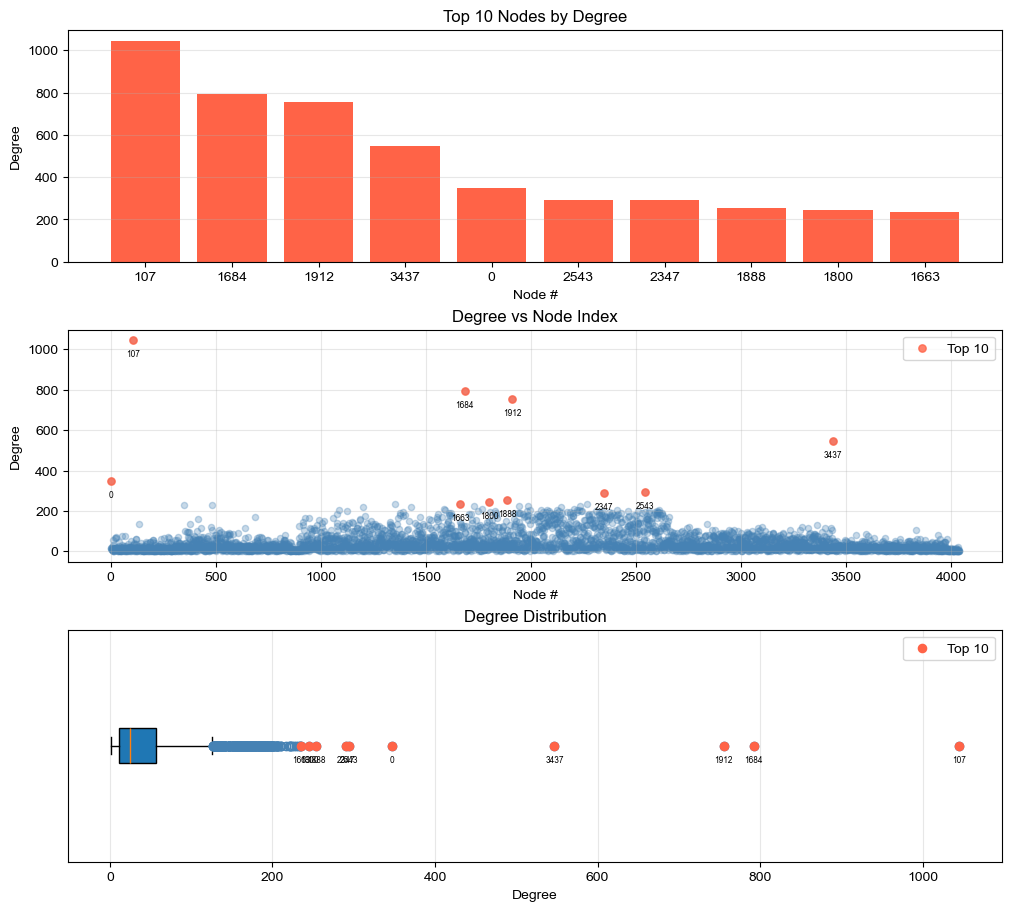

In [72]:
top = np.argsort(degrees)[-10:][::-1]

fig = plt.figure(figsize=(10, 9), constrained_layout=True)
color = "steelblue"
color_top = "tomato"
gs = fig.add_gridspec(3, 2)

# Bar plot
ax0 = fig.add_subplot(gs[0, :])
ax0.bar(range(10), degrees[top], color=color_top)
ax0.set_title("Top 10 Nodes by Degree")
ax0.set_xlabel("Node #")
ax0.set_ylabel("Degree")
ax0.set_xticks(range(10))
ax0.set_xticklabels(top)
ax0.grid(True, alpha=0.3, axis="y")

# Scatter plot

ax1 = fig.add_subplot(gs[1, :])
ax1.scatter(nodes, degrees[nodes], alpha=0.3, color=color, s=20)
ax1.set_title("Degree vs Node Index")
ax1.set_xlabel("Node #")
ax1.set_ylabel("Degree")
ax1.grid(True, alpha=0.3)
# Add the top 10 nodes on top of the scatter plot
ax1.scatter(top, degrees[top], color=color_top, alpha=0.8, label="Top 10", s=28, zorder=3)
for node in top:
    ax1.annotate(f"{node}", (node, degrees[node]), xytext=(0, -10), textcoords="offset points", ha="center", va="center", fontsize=6)
ax1.legend()

# Boxplot

ax2 = fig.add_subplot(gs[2, :])
bp = ax2.boxplot(
    [degrees],
    patch_artist=True,
    orientation="horizontal",
)
ax2.set_yticks([])
bp["fliers"][0].set_markeredgecolor(color)
# Add the top 10 nodes on the boxplot
ax2.scatter(degrees[top], [1]*len(top), color=color_top, alpha=1, label="Top 10", s=35, zorder=3)
for node in top:
    ax2.annotate(f"{node}", (degrees[node], 1), xytext=(0, -10), textcoords="offset points", ha="center", va="center", fontsize=6)
ax2.legend()

ax2.set_title("Degree Distribution")
ax2.set_xlabel("Degree")
ax2.grid(True, alpha=0.3, axis="x")
plt.show()


There are very few nodes with high degree, and many nodes with low degree. This is a common pattern in real-world networks, often referred to as a "power-law" distribution.

# Centrality measures

## Betweenness centrality
> This is a **node-distance** based centrality measure, which means it's based on the shortest paths between nodes. It measures how many of such shortest paths pass through a given node.

For a node $v$ in a **undirected** graph, betweenness is:

$$
C_B(v)=\sum_{\{s,t\}\subset V\setminus\{v\}} \frac{\sigma_{st}(v)}{\sigma_{st}}
$$

where:

- $\sigma_{st}$ = number of shortest paths between $s$ and $t$
- $\sigma_{st}(v)$ = number of those shortest paths that pass through $v$

---

Here I'm using the **Brandes Algorithm**:

$$
C_B(v) = \sum_{s \neq v} \delta_s(v)
\qquad
\delta_s(v) = \sum_{w:\;v \in P_s(w)} \frac{\sigma_{sv}}{\sigma_{sw}} (1 + \delta_s(w))
$$

where:

- $P_s(w)$ = set of predecessors of $w$ in the shortest paths from $s$ to $w$.
- $\delta_s(v)$ = dependency of source node $s$ on node $v$.

In other words, $w$ is a children of node $v$ in all the shortest path tree rooted at $s$.

_For each_ source node $s$:
1. **Forward Step**: Do a *BFS* to find the shortest path(s) `s ->  all other nodes`. Results:
    1. S = [ `All nodes, sorted in order of distance from root node s` ]
    4. d = { n: `Minimum path distance from root node s to this node` }
    3. $\sigma$ = { n: `How many such shortest path(s) exist from root node s to this node` }
    2. P = { n: [`Predecessors in each of such shortest path(s) from root node s to this node`] }
2. **Backward Step**: Do a *backwards accumulation* of dependencies, starting from the furthest nodes to $s$. Results:
    1. $\delta$ = { n: `How many shortest paths from root node s to all other nodes pass through this node` }
    2. $C_B$ = { n: `Betweenness centrality of this node` }

In [73]:
def betweenness_centrality(adjacencies, normalized=True): # Brandes Algorithm
    betweenness = {n: 0.0 for n in adjacencies}
    norm = (len(adjacencies) - 1) * (len(adjacencies) - 2) if normalized else 1 # maximum possible betweenness for a node (if all shortest paths between all pairs of nodes pass through it)

    # For each node as source
    for source in adjacencies:
        S = []                          # Sorted nodes in order of distance from source
        D = {n: -1 for n in adjacencies}      # For each node, the shortest distance from source
        sigma = {n: 0 for n in adjacencies}   # For each node, how many of such short paths from source
        P = {n: [] for n in adjacencies}      # For each node, the one predecessor in the shortest path(s) from source to it

        # Initialization for source
        sigma[source] = 1               # Only one shortest path to self
        D[source] = 0                   # Dist. to self is 0
        Q = [source]                    # Queue for BFS as starting point
        
        # 1. Forward step (BFS)
        while Q:                        # While there are nodes to explore 
            n = Q.pop(0)                # Dequeue (FIFO) next node to explore
            S.append(n)                 # Append to stack for later backtracking
            for w in adjacencies[n]:
                if D[w] < 0:            # For each NOT VISITED child 
                    Q.append(w)             # Enqueue for exploration and
                    D[w] = D[n] + 1         # Is one more step distant to source compared to current node
                if D[w] == D[n] + 1:    # For each (1) ALREADY VISITED child for which (2) the current node is on a shortest path to it
                    sigma[w] += sigma[n]    # Increase the number of shortest paths to it considering (!) the number of shortest paths to the current node
                    P[w].append(n)          # Add the current node as a predecessor on the shortest path to it

        # All the graph was traversed, now we have the shortest paths from source
        
        # 2. Backward step (dependencies aggregation - find out how much source depends on each node for its shortest paths)
        delta = {w: 0 for w in adjacencies}   # For each node, ratio of shortest paths from source to any node that pass through it ("dependency")
        while S:                        
            w = S.pop()                         # Start from the farthest node and go back to source
            coeff = (1 + delta[w]) / sigma[w]   # Ratio of shortest paths from source to any node that pass through the current node
            for n in P[w]:                      # For each predecessors in the shortest paths to the current node
                delta[n] += sigma[n] * coeff        # Dependency of the predecessor is increased by the dependency of the current node weighted by the ratio of shortest paths to it from source that pass through the current node
            if w != source:
                betweenness[w] += delta[w] / norm      # Betweenness of the current node is increased by its dependency (except for source node)
    return betweenness

Top 10 nodes by betweenness:
Node 107: 0.4805
Node 1684: 0.3378
Node 3437: 0.2361
Node 1912: 0.2293
Node 1085: 0.1490
Node 0: 0.1463
Node 698: 0.1153
Node 567: 0.0963
Node 58: 0.0844
Node 428: 0.0643


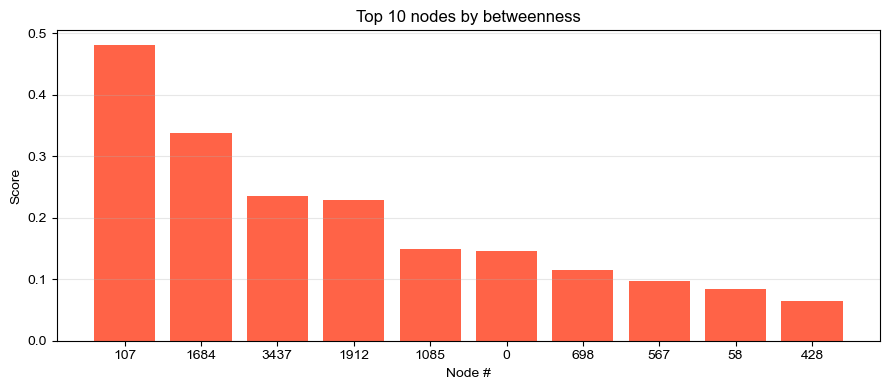

In [74]:
import networkx as nx

# According to betweeness criterion (how many shortest paths from any node to any other node pass through it)
c = betweenness_centrality(adjacencies) # centrality score of each node

# Sanity check with NetworkX implementation
c_nx = nx.betweenness_centrality(graph)
diff = np.array([abs(c[n] - c_nx[n]) for n in adjacencies])   # Difference between my implementation and NetworkX for each node
assert np.allclose(diff, 0.0, atol=1e-4), "Betweenness centrality values do not match NetworkX implementation!"

# List top 10 nodes with highest betweenness centrality score
display_top_centrality(c, "betweenness", save=True)

## PageRank centrality
> This is a **spectral 👻** centrality measure, which means it's based on eigen-properties of the adjacency matrix. It measures how "important" a node is, based on the importance of its neighbors (scaled by the number of outgoing links). Since this recursive definition, we either use the power iteration method, or we can directly compute the eigenvector of the adjacency matrix.

For a node $v$ it is defined as:

$$
C_{PR}(v) = \alpha \sum_{u} A_{uv}\frac{C_{PR}(u)}{deg(u)} + \beta
$$

where:

- $\alpha$ = `damping factor` (usually set to 0.85)
- $\beta$ = `teleportation factor` (usually set to (1 - $\alpha$) / N, where N is the number of nodes)
- $A_{uv}$ = `adjacency of u->v (=v->u)` (1 if there is an edge from $u$ to $v$, 0 otherwise)

---

If we're interested in all nodes' centrality, we can use its analogous **vector form**:

$$
\begin{aligned}
\mathbf{C}
&= \alpha \mathbf{A}^\top \mathbf{D}^{-1}\mathbf{C} + \beta\mathbf{1} \\[10pt]
&= \beta(I - \alpha \mathbf{A}^\top \mathbf{D}^{-1})^{-1}\mathbf{1}
&= \begin{bmatrix}
        C(v_1) \\
        C(v_2) \\
        \vdots \\
        C(v_N)
    \end{bmatrix} 
\end{aligned}
$$

---

Since the matrix inversion above can easily become computationally too expensive ($O(N^3)$), I used the **power iteration** method:

1. Initialize $\mathbf{C}^{(0)}$ with some initial values (e.g., uniform distribution).
2. For each node $v$, update using $ C^{(k+1)}(v) = \alpha \sum_{u\in\mathcal N(v)} \frac{C^{(k)}(u)}{deg(u)} + \beta $
3. Repeat until convergence (i.e., small enough increase like $\|\mathbf{C}^{(k+1)} - \mathbf{C}^{(k)}\| < \epsilon$ for some small threshold $\epsilon$).

Algorithm intuition: at each iteration, each node’s centrality is increased by a fraction of its **parents’ (incoming neighbors’)** centrality, where each parent splits its centrality evenly across its outgoing edges (so the fraction is “1 / parent’s out-degree”). The teleportation factor $\beta$ ensures that even nodes with no incoming edges (or in “poor” positions in the graph) still receive some baseline centrality, representing extra-graph importance.

In [75]:
def pagerank_centrality(adjacencies, alpha, beta, eps=1e-6): # Using Power Iteration method
    N = len(adjacencies)
    d_out = {node: len(adjacencies[node]) for node in adjacencies}
    assert abs(beta - (1 - alpha)) < 1e-9, f"Beta should be (1 - alpha). Got beta={beta}, expected {1 - alpha}"
    
    c_prev = {node: 1.0 / N for node in adjacencies}    # PageRank mass per node (sums to 1 across all nodes)
    c_new  = {node: 0.0     for node in adjacencies}

    while True:
        # 1. teleportation
        # add teleportation mass to each node (sums to 1 - alpha across all nodes)
        for node in adjacencies:
            c_new[node] = beta / N

        # 2. dangling mass
        # distribute mass from nodes with no outgoing links (sums to alpha * dangling across all nodes)
        dangling = sum(c_prev[node] for node in adjacencies if d_out[node] == 0)
        for node in adjacencies:
            c_new[node] += alpha * dangling / N

        # 3. link-following
        # distribute mass from nodes with outgoing links (sums to alpha * (1 - dangling) across all nodes)
        for node in adjacencies:
            if d_out[node] == 0:
                continue    # dangling nodes do not contribute to link-following mass
            share = alpha * c_prev[node] / d_out[node]  # each outgoing link gets an equal share of the node's PageRank mass weighted by alpha
            for child in adjacencies[node]:
                c_new[child] += share

        # check numerical stability (should be 1.0 at each step)
        assert abs(sum(c_new.values()) - 1.0) < 1e-6, f"PageRank mass is not conserved! Sum is {sum(c_new.values())}"

        # convergence check
        if sum(abs(c_new[node] - c_prev[node]) for node in adjacencies) < eps:
            break

        c_prev = c_new.copy()

    return c_new

Top 10 nodes by PageRank:
Node 3437: 0.0076
Node 107: 0.0069
Node 1684: 0.0063
Node 0: 0.0062
Node 1912: 0.0038
Node 348: 0.0023
Node 686: 0.0022
Node 3980: 0.0022
Node 414: 0.0018
Node 483: 0.0013


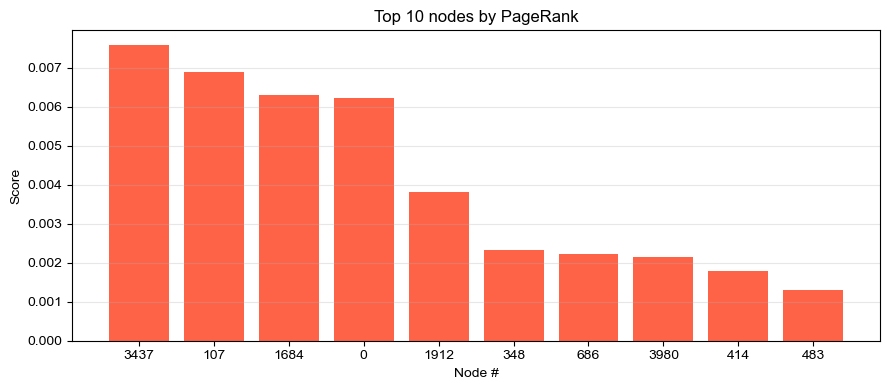

In [76]:
import networkx as nx

# According to PageRank criterion (how many shortest paths from any node to any other node pass through it)
c = pagerank_centrality(adjacencies, alpha = 0.85, beta = 0.15) # centrality score of each node

# Sanity check with NetworkX implementation
c_nx = nx.pagerank(graph, alpha=0.85)
diff = np.array([abs(c[n] - c_nx[n]) for n in adjacencies])   # Difference between my implementation and NetworkX for each node
assert np.allclose(diff, 0.0, atol=1e-4), f"PageRank centrality values do not match NetworkX implementation! (Check bad indices: {np.flatnonzero(diff > 1e-4)})"

# List top 10 nodes with highest PageRank centrality score
display_top_centrality(c, "PageRank", save=True)